### Lab 01b: Binary Linear Classifier

In this lab you will try making a binary linear classifier using the [Palmer Penguins dataset](https://allisonhorst.github.io/palmerpenguins/).

In [1]:
import sklearn
from palmerpenguins import load_penguins
from mlxtend.plotting import plot_decision_regions

Matplotlib is building the font cache; this may take a moment.


The dataset is loaded as a [Pandas dataframe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).  

In [2]:
df = load_penguins()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


For simplicity we will drop any rows with missing values (encoded as NaNs).

In [3]:
df.dropna(inplace=True)
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


Let's select just the Adelie and Chinstrap penguins.

In [4]:
df = df[(df['species']=='Adelie')|(df['species']=='Chinstrap')]

Now we will grab the flipper length and bill length to be the features (stored in ``X``) and the species as the labels (stored in ``y``).

In [5]:
X = df[['flipper_length_mm','bill_length_mm']].values
y = df['species'].map({'Adelie':0,'Chinstrap':1}).values

## Exercises

1. Fit a binary linear classifier using scikit-learn (see ``sklearn.linear_model.LogisticRegression``).

Plot the resulting classifier using ``plot_decision_regions(X, y, clf=model)``.


<Axes: >

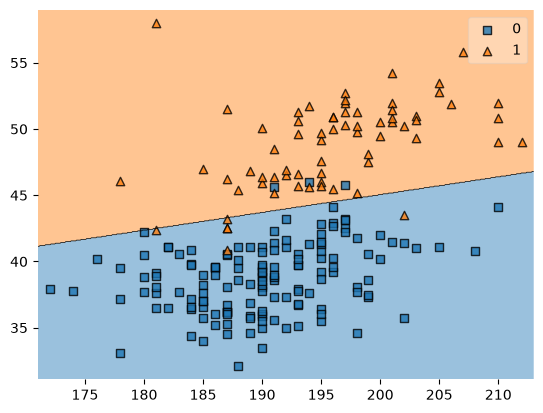

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

plot_decision_regions(X, y, clf=model)

2. Print out the coefficients of the line (``model.coef_``).  Interpret these values (in terms of the direction of the line and also what they tell us about how the classifier operates).

In [7]:
print(model.coef_)
print(model.intercept_)

[[-0.15845623  1.17936568]]
[-21.43521153]


Since the bill length coefficient has a larger absolute value than the flipper length coefficient, bill length has a bigger effect on prediction. 

Since the bill length coefficient is positive and its absolute is larger, longer bills increase the chance of the model predicting Chinstrap more strongly.

Since the flipper length coefficient is negative, longer flippers increase the chance of the model predicting Adelie slightly.

3. Calculate and print out the accuracy of the classifier using the `.score` function.  Interpret this value.

In [8]:
accuracy = model.score(X, y)
print(accuracy)

0.9579439252336449


The classifier correctly classified ~95.8% of the penguins using flipper length and bill length. Since it is high, there is a strong linear separation between the two species; however, since it's not 100%, some penguins overlap in the feature space.

4. Try different combinations of features and print out the accuracy for each one.  Interpret your results.

In [9]:
feature_sets = [
    ['flipper_length_mm', 'bill_length_mm'],
    ['flipper_length_mm', 'bill_depth_mm'],
    ['flipper_length_mm', 'body_mass_g'],
    ['bill_length_mm', 'bill_depth_mm'],
    ['bill_length_mm', 'body_mass_g'],
    ['bill_depth_mm', 'body_mass_g']
]

for features in feature_sets:
    X_temp = df[features].values
    y_temp = df['species'].map({'Adelie': 0, 'Chinstrap': 1}).values

    temp_model = LogisticRegression()
    temp_model.fit(X_temp, y_temp)

    accuracy = temp_model.score(X_temp, y_temp)
    print(features, accuracy)

['flipper_length_mm', 'bill_length_mm'] 0.9579439252336449
['flipper_length_mm', 'bill_depth_mm'] 0.7383177570093458
['flipper_length_mm', 'body_mass_g'] 0.7383177570093458
['bill_length_mm', 'bill_depth_mm'] 0.9719626168224299
['bill_length_mm', 'body_mass_g'] 0.985981308411215
['bill_depth_mm', 'body_mass_g'] 0.6822429906542056


The best pair was bill length and body mass with an accuracy of ~98.6%. Since it is the highest, there is the strongest linear separation between the two species. The pairs with bill length generally performed better. The weakest was bill depth and body mass with ~68.2% accuracy.